In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


LOADING MODELS
✅ Models loaded

RUNNING PIPELINE TEST - ALL IMAGES
Found 4 images

Image: test_glioma.jpg

[STEP 1] Classification...
  Label      : glioma
  Confidence : 0.9657 (96.57%)
  All preds  : {'glioma': 0.9657, 'meningioma': 0.0241, 'no_tumor': 0.0064, 'pituitary': 0.0037}
  ✅ Classification passed

[STEP 2] Segmentation...
  Mask shape        : (384, 384)
  Mask unique values: [0 1]
  ✅ Segmentation passed

[STEP 3] GradCAM...
  Heatmap shape   : (12, 12)
  Heatmap min/max : 0.0000 / 1.0000
  ✅ GradCAM passed

[STEP 4] Tumor Size Estimation...
  Tumor Pixels   : 4835 px
  Area           : 1208.75 mm²  |  12.0875 cm²
  Diameter       : 39.23 mm  |  3.923 cm
  Brain Coverage : 3.28%
  Bounding Box   : 4.4 cm x 2.7 cm
  ✅ Tumor size estimation passed

  📋 SUMMARY
  Prediction     : glioma (96.57%)
  Tumor Area     : 12.0875 cm²
  Tumor Diameter : 3.923 cm
  Brain Coverage : 3.28%
  ✅ ALL 4 STEPS PASSED


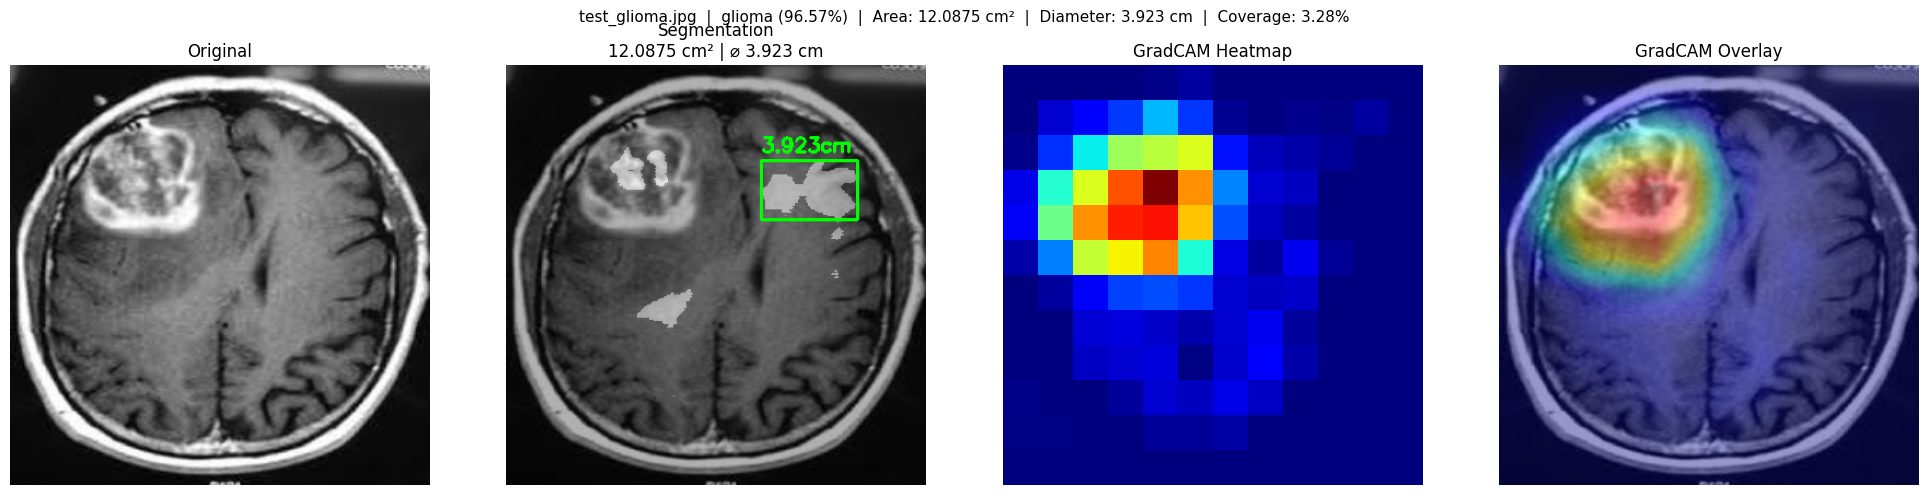

Image: test_meningioma.jpg

[STEP 1] Classification...
  Label      : meningioma
  Confidence : 0.8944 (89.44%)
  All preds  : {'glioma': 0.0266, 'meningioma': 0.8944, 'no_tumor': 0.0273, 'pituitary': 0.0516}
  ✅ Classification passed

[STEP 2] Segmentation...
  Mask shape        : (384, 384)
  Mask unique values: [0 1]
  ✅ Segmentation passed

[STEP 3] GradCAM...
  Heatmap shape   : (12, 12)
  Heatmap min/max : 0.0000 / 1.0000
  ✅ GradCAM passed

[STEP 4] Tumor Size Estimation...
  Tumor Pixels   : 1259 px
  Area           : 314.75 mm²  |  3.1475 cm²
  Diameter       : 20.02 mm  |  2.002 cm
  Brain Coverage : 0.85%
  Bounding Box   : 2.15 cm x 1.85 cm
  ✅ Tumor size estimation passed

  📋 SUMMARY
  Prediction     : meningioma (89.44%)
  Tumor Area     : 3.1475 cm²
  Tumor Diameter : 2.002 cm
  Brain Coverage : 0.85%
  ✅ ALL 4 STEPS PASSED


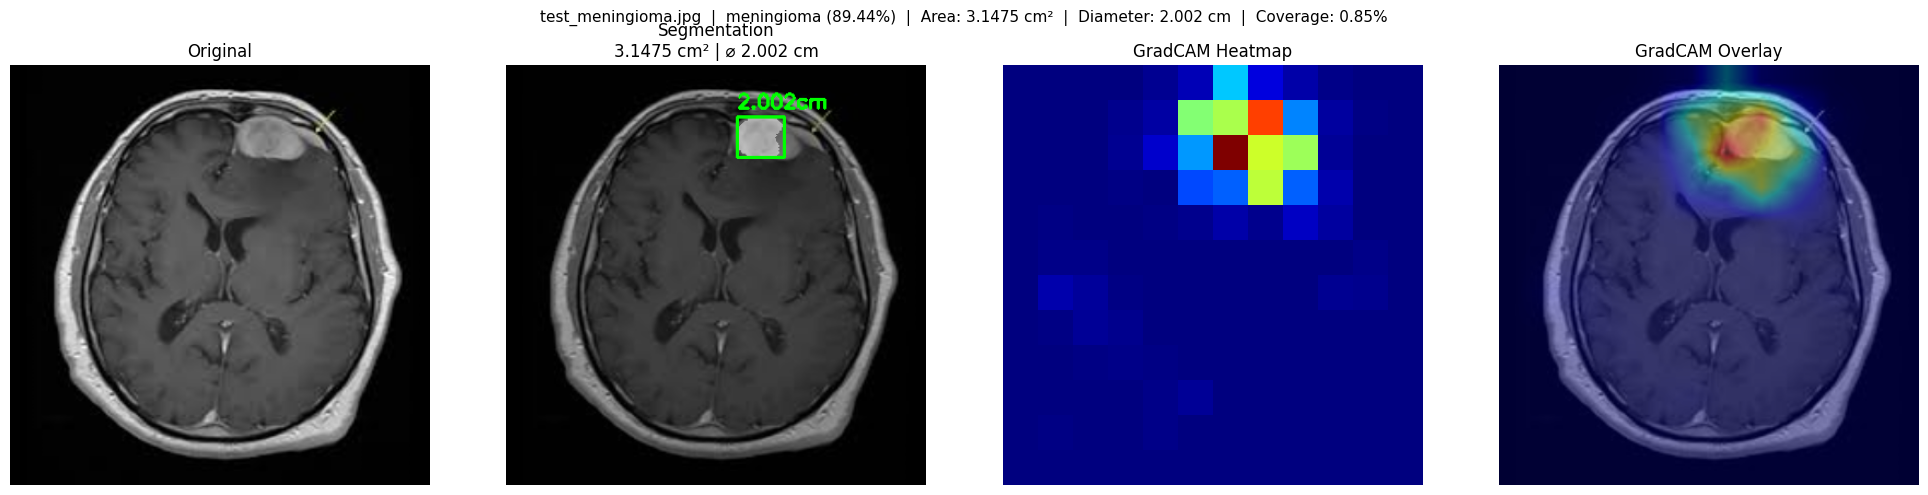

Image: test_pituitary.jpg

[STEP 1] Classification...
  Label      : pituitary
  Confidence : 0.8575 (85.75%)
  All preds  : {'glioma': 0.0521, 'meningioma': 0.0504, 'no_tumor': 0.0399, 'pituitary': 0.8575}
  ✅ Classification passed

[STEP 2] Segmentation...
  Mask shape        : (384, 384)
  Mask unique values: [0 1]
  ✅ Segmentation passed

[STEP 3] GradCAM...
  Heatmap shape   : (12, 12)
  Heatmap min/max : 0.0000 / 1.0000
  ✅ GradCAM passed

[STEP 4] Tumor Size Estimation...
  Tumor Pixels   : 426 px
  Area           : 106.5 mm²  |  1.065 cm²
  Diameter       : 11.64 mm  |  1.164 cm
  Brain Coverage : 0.29%
  Bounding Box   : 1.15 cm x 0.75 cm
  ✅ Tumor size estimation passed

  📋 SUMMARY
  Prediction     : pituitary (85.75%)
  Tumor Area     : 1.065 cm²
  Tumor Diameter : 1.164 cm
  Brain Coverage : 0.29%
  ✅ ALL 4 STEPS PASSED


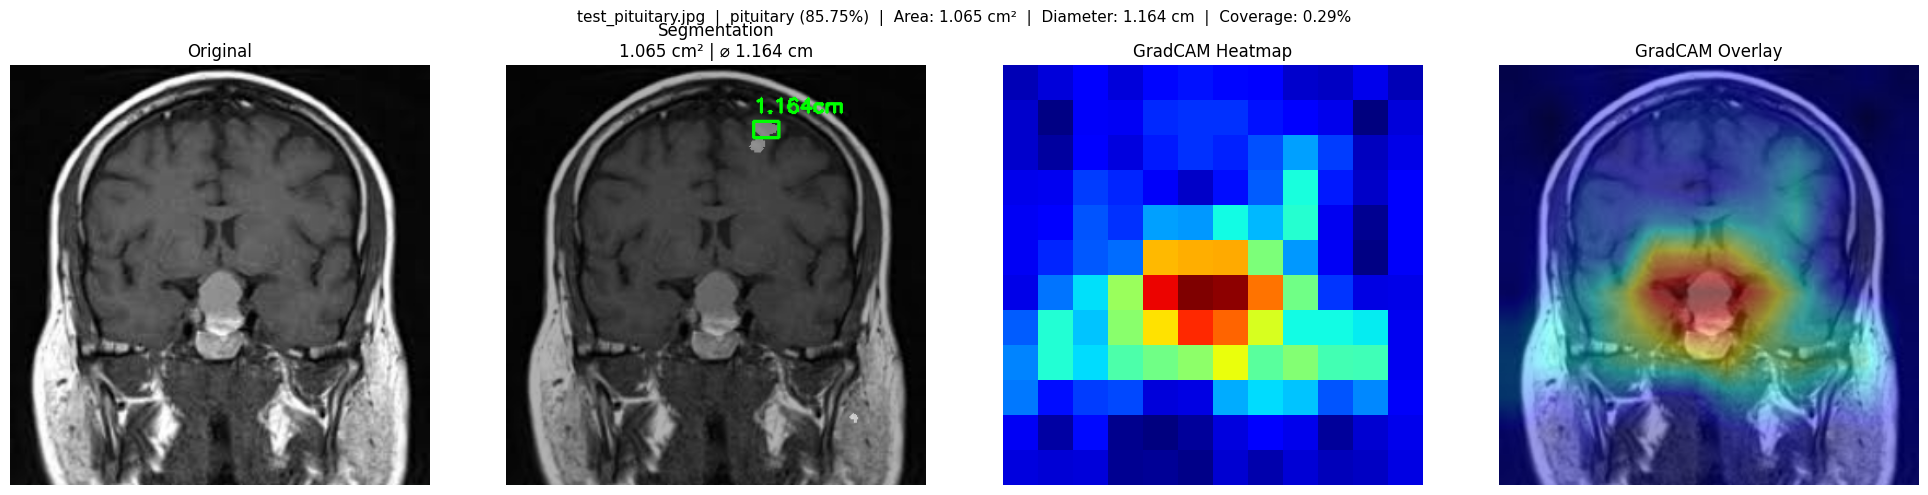

Image: test_no tumor.jpg

[STEP 1] Classification...
  Label      : no_tumor
  Confidence : 0.9217 (92.17%)
  All preds  : {'glioma': 0.0271, 'meningioma': 0.0276, 'no_tumor': 0.9217, 'pituitary': 0.0236}
  ✅ Classification passed

[STEP 2] Segmentation...
  Mask shape        : (384, 384)
  Mask unique values: [0 1]
  ✅ Segmentation passed

[STEP 3] GradCAM...
  Heatmap shape   : (12, 12)
  Heatmap min/max : 0.0295 / 1.0000
  ✅ GradCAM passed

[STEP 4] Tumor Size Estimation...
  Tumor Pixels   : 823 px
  Area           : 205.75 mm²  |  2.0575 cm²
  Diameter       : 16.19 mm  |  1.619 cm
  Brain Coverage : 0.56%
  Bounding Box   : 0.8 cm x 2.6 cm
  ✅ Tumor size estimation passed

  📋 SUMMARY
  Prediction     : no_tumor (92.17%)
  Tumor Area     : 2.0575 cm²
  Tumor Diameter : 1.619 cm
  Brain Coverage : 0.56%
  ✅ ALL 4 STEPS PASSED


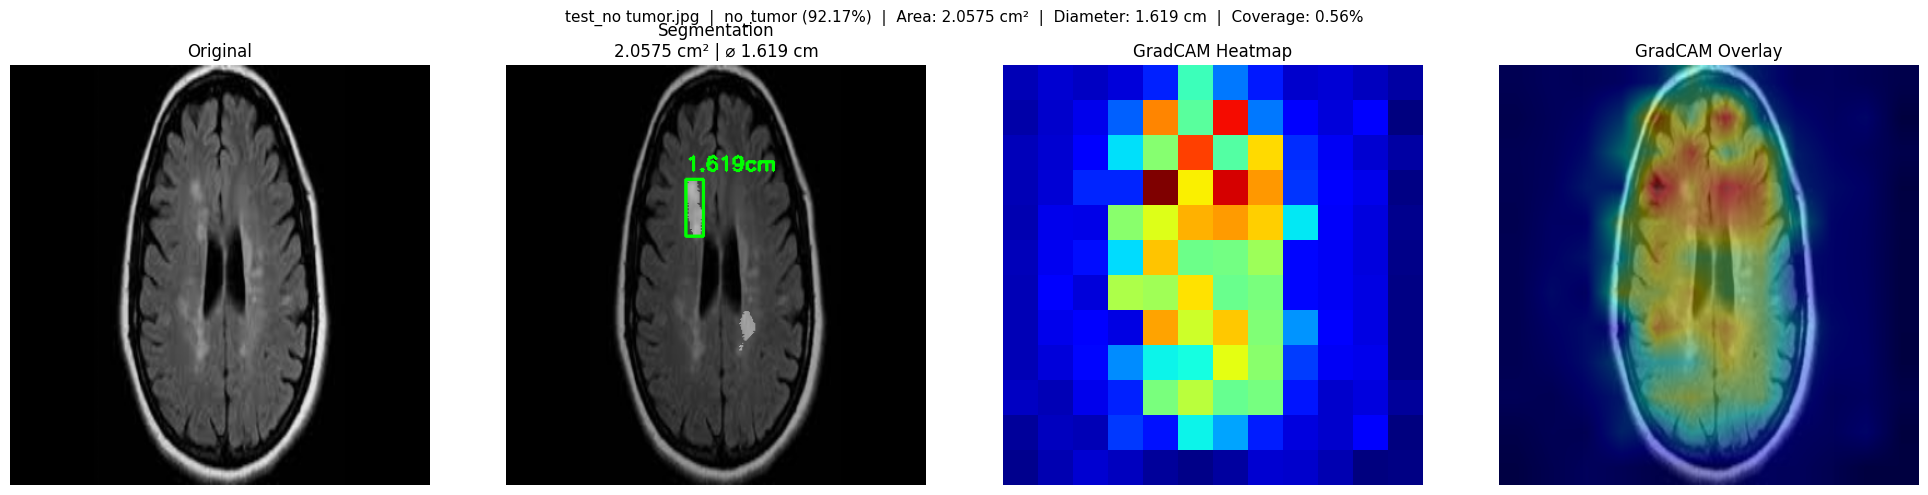


FINAL SUMMARY
  Total Images : 4
  ✅ Passed    : 4
  ❌ Failed    : 0


In [4]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_prep

# ========================================
# PATH CONFIGURATION
# ========================================
BASE_DIR = "/content/drive/MyDrive/Project work"
CLASS_MODEL_PATH = BASE_DIR + "/models/Classification/Tumor_v2s_clean.keras"
SEG_MODEL_PATH   = BASE_DIR + "/models/Segmentation/unet_lgg_segmentation_u-net.keras"
TEST_DIR         = BASE_DIR + "/Test Data"

IMG_SIZE = 384
SEG_SIZE = 256
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
PIXEL_SPACING_MM = 0.5
MM2_TO_CM2 = 0.01

# ========================================
# LOAD MODELS
# ========================================
print("="*50)
print("LOADING MODELS")
print("="*50)
class_model = tf.keras.models.load_model(CLASS_MODEL_PATH)
seg_model   = tf.keras.models.load_model(SEG_MODEL_PATH, compile=False)
print("✅ Models loaded")

# ========================================
# GRADCAM SETUP
# ========================================
base_model = class_model.get_layer("efficientnetv2-s")
head_layers = []
reached = False
for layer in class_model.layers:
    if layer.name == "efficientnetv2-s":
        reached = True
        continue
    if reached:
        head_layers.append(layer)

# ========================================
# HELPER FUNCTIONS
# ========================================
def load_class_image(path):
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.utils.img_to_array(img)
    img = effv2_prep(img)
    img = np.expand_dims(img, axis=0)
    return img

def get_gradcam_heatmap(img_tensor):
    img_tensor_cast = tf.cast(img_tensor, tf.float32)
    conv_output = base_model(img_tensor_cast, training=False)
    conv_var = tf.Variable(conv_output)
    with tf.GradientTape() as tape:
        tape.watch(conv_var)
        x = conv_var
        for layer in head_layers:
            x = layer(x)
        predictions = x
        class_index = tf.argmax(predictions[0])
        class_score = predictions[:, class_index]
    grads = tape.gradient(class_score, conv_var)
    if grads is None:
        return np.zeros((12, 12))
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_output[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def estimate_tumor_size(mask):
    tumor_pixels  = int(np.sum(mask))
    total_pixels  = mask.shape[0] * mask.shape[1]
    area_mm2      = tumor_pixels * (PIXEL_SPACING_MM ** 2)
    area_cm2      = area_mm2 * MM2_TO_CM2
    diameter_mm   = 2 * np.sqrt(area_mm2 / np.pi)
    diameter_cm   = diameter_mm / 10
    tumor_percent = (tumor_pixels / total_pixels) * 100
    contours, _   = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bbox_info = None
    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        bbox_info = {
            "x": x, "y": y, "w": w, "h": h,
            "width_cm":  round((w * PIXEL_SPACING_MM) / 10, 2),
            "height_cm": round((h * PIXEL_SPACING_MM) / 10, 2),
        }
    return {
        "tumor_pixels":  tumor_pixels,
        "area_mm2":      round(area_mm2, 2),
        "area_cm2":      round(area_cm2, 4),
        "diameter_mm":   round(diameter_mm, 2),
        "diameter_cm":   round(diameter_cm, 3),
        "tumor_percent": round(tumor_percent, 2),
        "bbox":          bbox_info
    }

# ========================================
# TEST CASE - ALL IMAGES
# ========================================
print("\n" + "="*50)
print("RUNNING PIPELINE TEST - ALL IMAGES")
print("="*50)

all_files = [f for f in os.listdir(TEST_DIR)
             if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))]

print(f"Found {len(all_files)} images\n")

passed = 0
failed = 0

for file in all_files:
    image_path = os.path.join(TEST_DIR, file)
    print("="*50)
    print(f"Image: {file}")

    try:
        # --- STEP 1: CLASSIFICATION ---
        print("\n[STEP 1] Classification...")
        orig       = cv2.imread(image_path)
        orig       = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
        img_class  = load_class_image(image_path)
        img_tensor = tf.convert_to_tensor(img_class)
        preds      = class_model(img_tensor, training=False)[0].numpy()
        class_id   = np.argmax(preds)
        label      = CLASS_NAMES[class_id]
        confidence = preds[class_id]
        print(f"  Label      : {label}")
        print(f"  Confidence : {confidence:.4f} ({confidence:.2%})")
        print(f"  All preds  : { {CLASS_NAMES[i]: round(float(preds[i]),4) for i in range(4)} }")
        assert confidence > 0.0
        print("  ✅ Classification passed")

        # --- STEP 2: SEGMENTATION ---
        print("\n[STEP 2] Segmentation...")
        img_seg = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img_seg = cv2.resize(img_seg, (SEG_SIZE, SEG_SIZE))
        img_seg = img_seg / 255.0
        img_seg = np.expand_dims(img_seg, (0, -1))
        mask    = seg_model(img_seg, training=False)[0].numpy()
        mask    = (mask > 0.5).astype(np.uint8)
        mask    = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        print(f"  Mask shape        : {mask.shape}")
        print(f"  Mask unique values: {np.unique(mask)}")
        assert mask.shape == (IMG_SIZE, IMG_SIZE)
        print("  ✅ Segmentation passed")

        # --- STEP 3: GRADCAM ---
        print("\n[STEP 3] GradCAM...")
        heatmap = get_gradcam_heatmap(img_tensor)
        print(f"  Heatmap shape   : {heatmap.shape}")
        print(f"  Heatmap min/max : {heatmap.min():.4f} / {heatmap.max():.4f}")
        assert heatmap.max() > 0
        print("  ✅ GradCAM passed")

        # --- STEP 4: TUMOR SIZE ESTIMATION ---
        print("\n[STEP 4] Tumor Size Estimation...")
        size_info = estimate_tumor_size(mask)
        print(f"  Tumor Pixels   : {size_info['tumor_pixels']} px")
        print(f"  Area           : {size_info['area_mm2']} mm²  |  {size_info['area_cm2']} cm²")
        print(f"  Diameter       : {size_info['diameter_mm']} mm  |  {size_info['diameter_cm']} cm")
        print(f"  Brain Coverage : {size_info['tumor_percent']}%")
        if size_info['bbox']:
            print(f"  Bounding Box   : {size_info['bbox']['width_cm']} cm x {size_info['bbox']['height_cm']} cm")
        assert size_info['area_cm2'] >= 0
        print("  ✅ Tumor size estimation passed")

        # SUMMARY PER IMAGE
        print(f"\n  📋 SUMMARY")
        print(f"  Prediction     : {label} ({confidence:.2%})")
        print(f"  Tumor Area     : {size_info['area_cm2']} cm²")
        print(f"  Tumor Diameter : {size_info['diameter_cm']} cm")
        print(f"  Brain Coverage : {size_info['tumor_percent']}%")
        print("  ✅ ALL 4 STEPS PASSED")
        passed += 1

        # VISUALIZATION
        mask_vis     = np.uint8(mask * 255)
        mask_color   = cv2.applyColorMap(mask_vis, cv2.COLORMAP_HOT)
        mask_overlay = cv2.addWeighted(orig, 0.7, mask_color, 0.3, 0)

        if size_info['bbox']:
            b = size_info['bbox']
            cv2.rectangle(mask_overlay, (b['x'], b['y']),
                          (b['x']+b['w'], b['y']+b['h']), (0, 255, 0), 2)
            cv2.putText(mask_overlay, f"{size_info['diameter_cm']}cm",
                        (b['x'], b['y']-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        heatmap_uint8   = np.uint8(255 * heatmap_resized)
        heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        gradcam_overlay = cv2.addWeighted(orig, 0.6, heatmap_color, 0.4, 0)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(
            f"{file}  |  {label} ({confidence:.2%})  |  "
            f"Area: {size_info['area_cm2']} cm²  |  "
            f"Diameter: {size_info['diameter_cm']} cm  |  "
            f"Coverage: {size_info['tumor_percent']}%",
            fontsize=11
        )
        axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(cv2.cvtColor(mask_overlay, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Segmentation\n{size_info['area_cm2']} cm² | ⌀ {size_info['diameter_cm']} cm")
        axes[1].axis("off")

        axes[2].imshow(heatmap, cmap="jet")
        axes[2].set_title("GradCAM Heatmap")
        axes[2].axis("off")

        axes[3].imshow(cv2.cvtColor(gradcam_overlay, cv2.COLOR_BGR2RGB))
        axes[3].set_title("GradCAM Overlay")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  ❌ FAILED: {e}")
        failed += 1

# ========================================
# FINAL SUMMARY
# ========================================
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"  Total Images : {len(all_files)}")
print(f"  ✅ Passed    : {passed}")
print(f"  ❌ Failed    : {failed}")
print("="*50)